<h1><b>Regressão Logística</b><br>
<i>Conjunto de dados Diabetes Health Indicators</i></h1>

<b>Objetivo do modelo:</b><br>
Prever a probabilidade de um paciente ter diabetes sem o uso de variáveis clinicas

### Importação das Bibliotecas

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import shap

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text

from sklearn.metrics import roc_auc_score

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "utils")))

from plot_config import set_seaborn
set_seaborn()

### Configurações do experimento

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

TARGET = "diagnosed_diabetes"

DATA_PATH = "./../../data/raw/diabetes_health_indicators.csv"

### Importação e pré-visualização dos dados

In [3]:
df_columns = [
    "age",
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi",
    TARGET
]

df = pd.read_csv(DATA_PATH, usecols=df_columns)

pd.options.display.float_format = "{:.2f}".format

display(df.head(3))

print(f"{df.shape[0]} registros e {df.shape[1]} variáveis")

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.70,7.90,7.90,30.50,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.70,6.50,8.70,23.10,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.40,10.00,8.10,22.20,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.40,6.60,5.20,26.80,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.20,7.40,5.00,21.20,1


100000 registros e 14 variáveis


### Discretização exploratória com árvore

In [4]:
tree_discretizer = DecisionTreeClassifier(
    max_leaf_nodes=4,
    random_state=RANDOM_STATE
)

tree_discretizer.fit(df[["age"]], df[TARGET])

thresholds = sorted(
    [t for t in tree_discretizer.tree_.threshold if t != -2]
)

thresholds = [round(t) for t in thresholds]

print("Pontos de corte sugeridos:", thresholds)

print(export_text(tree_discretizer, feature_names=["age"]))

Pontos de corte sugeridos: [28, 48, 68]
|--- age <= 48.50
|   |--- age <= 28.50
|   |   |--- class: 0
|   |--- age >  28.50
|   |   |--- class: 1
|--- age >  48.50
|   |--- age <= 67.50
|   |   |--- class: 1
|   |--- age >  67.50
|   |   |--- class: 1



Criando as faixas

In [6]:
bins = [-np.inf] + thresholds + [np.inf]

labels = [f"Faixa_{i}" for i in range(len(bins) - 1)]

df["age_binned"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

Estatística por faixa

In [7]:
age_stats = (
    df.groupby("age_binned")[TARGET]
      .agg(["count", "mean"])
      .rename(columns={
          "count": "n",
          "mean": "diabetes_rate"
      })
)

display(age_stats)

,n,diabetes_rate
age_binned,,
Faixa_0,8932,0.47
Faixa_1,37278,0.56
Faixa_2,41310,0.63
Faixa_3,12480,0.72


### Separação treino/teste

In [8]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

### Definição das features

In [9]:
numeric_features = [
    "age",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi"
]

categorical_features = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status"
]

### Pipelines de transformação

In [10]:
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("interactions", PolynomialFeatures(
        degree=2,
        interaction_only=True,
        include_bias=False
    ))
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

### ColumnTransformer

In [11]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

### Pipeline do modelo

In [12]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        solver="saga"
    ))
])

### Espaço de hiperparâmetros

In [13]:
param_dist = {
    "classifier__C": np.logspace(-4, 2, 100),
    "classifier__l1_ratio": [0, 0.5, 1]
}

### Cross Validation

In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

### Random Search

In [16]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': array([1.0000...00000000e+02]), 'classifier__l1_ratio': [0, 0.5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default val

### Melhor modelo

In [17]:
best_model = random_search.best_estimator_

print("Melhores parâmetros:")
print(random_search.best_params_)

print("ROC AUC médio (CV):")
print(random_search.best_score_)

Melhores parâmetros:
{'classifier__l1_ratio': 1, 'classifier__C': np.float64(0.011497569953977356)}
ROC AUC médio (CV):
0.6123102542242506


### Avaliação no teste

In [18]:
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_prob)

print("ROC AUC Teste:", test_auc)

ROC AUC Teste: 0.6020240104166666


### Análise de coeficientes

In [19]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = best_model.named_steps[
    "classifier"
].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
})

coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df.sort_values("abs_coef", ascending=False).head(20)

,feature,coef,abs_coef
0,num__age,0.28,0.28
2,num__physical_activity_minutes_per_week,-0.19,0.19
6,num__bmi,0.16,0.16
3,num__diet_score,-0.06,0.06
5,num__screen_time_hours_per_day,0.03,0.03
18,num__physical_activity_minutes_per_week diet_s...,0.01,0.01
8,num__age physical_activity_minutes_per_week,-0.01,0.01
41,cat__employment_status_Retired,-0.01,0.01
7,num__age alcohol_consumption_per_week,-0.01,0.01
27,num__screen_time_hours_per_day bmi,0.01,0.01


### SHAP

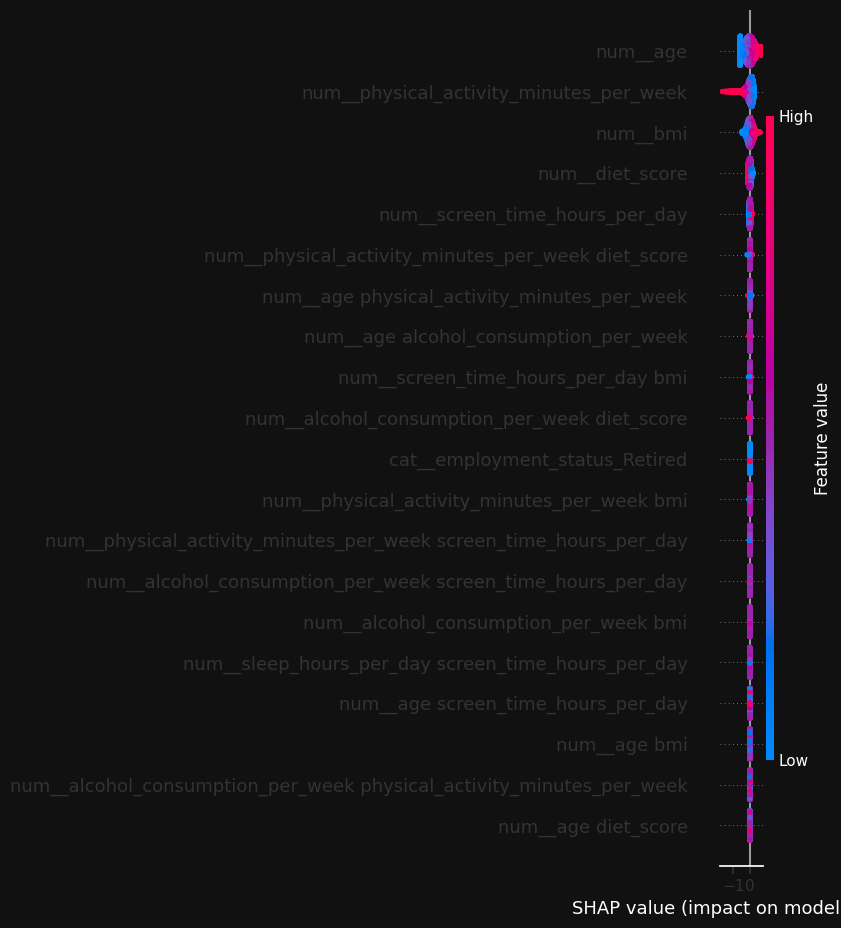

In [20]:
X_train_transformed = best_model.named_steps[
    "preprocessor"
].transform(X_train)

explainer = shap.LinearExplainer(
    best_model.named_steps["classifier"],
    X_train_transformed
)

shap_values = explainer(X_train_transformed)

shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names
)